# Updated SimpleRNN IMDB Sentiment Model


In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import re

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Input, Embedding, SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, TerminateOnNaN

# Reproducibility
tf.keras.utils.set_random_seed(42)

## 1. Load the IMDB dataset

In [2]:
max_features = 10000  # vocabulary size
max_len = 500          # review sequence length

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=max_features)

print(f"Training data shape: {X_train.shape}, Training labels shape: {y_train.shape}")
print(f"Testing data shape: {X_test.shape}, Testing labels shape: {y_test.shape}")

Training data shape: (25000,), Training labels shape: (25000,)
Testing data shape: (25000,), Testing labels shape: (25000,)


In [3]:
# Inspect one sample before padding
sample_review = X_train[0]
sample_label = y_train[0]

print(f"Sample label: {sample_label}")
print(f"Sample review length before padding: {len(sample_review)}")
print(sample_review[:30])

Sample label: 1
Sample review length before padding: 218
[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480]


In [4]:
# Mapping word indexes back to words, only for understanding the dataset
word_index = imdb.get_word_index()
reverse_word_index = {value: key for key, value in word_index.items()}

decoded_review = " ".join([reverse_word_index.get(i - 3, "?") for i in sample_review])
decoded_review[:1000]

"? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for ? and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also ? to the two little boy's that played the ? of norman and paul they were just brilliant children are often left out of the ? list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for what they have done don't you th

## 2. Pad the sequences

Padding makes every review the same length. Because the model uses `mask_zero=True`, the RNN will ignore padded zeros.

In [5]:
X_train = sequence.pad_sequences(X_train, maxlen=max_len)
X_test = sequence.pad_sequences(X_test, maxlen=max_len)

print(f"X_train shape after padding: {X_train.shape}")
print(f"X_test shape after padding: {X_test.shape}")

X_train shape after padding: (25000, 500)
X_test shape after padding: (25000, 500)


## 3. Build the updated SimpleRNN model

The online notebook used `SimpleRNN(..., activation='relu')`. It can look good sometimes, but your own notebook showed `nan` loss because ReLU in a recurrent loop can explode. This version stays SimpleRNN but is more stable and more modern.

In [6]:
tf.keras.backend.clear_session()

model = Sequential(name="updated_simple_rnn_imdb")

model.add(Input(shape=(max_len,)))
model.add(Embedding(input_dim=max_features, output_dim=128, mask_zero=True, name="embedding"))

# SimpleRNN layer only; no LSTM/GRU used
model.add(SimpleRNN(128, activation="tanh", name="simple_rnn"))

# Small classification head for better learning/generalization
model.add(Dropout(0.3, name="dropout_1"))
model.add(Dense(64, activation="relu", name="dense_64"))
model.add(Dropout(0.3, name="dropout_2"))
model.add(Dense(1, activation="sigmoid", name="output"))

optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005, clipnorm=1.0)

model.compile(
    optimizer=optimizer,
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "updated_simple_rnn_imdb"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 500, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,321,217 (5.04 MB)

 Trainable params: 1,321,217 (5.04 MB)

 Non-trainable params: 0 (0.00 B)

## 4. Train with stronger callbacks

In [7]:
callbacks = [
    TerminateOnNaN(),
    EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        mode="max",
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=1,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        "best_simple_rnn_imdb.keras",
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1
    )
]

history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    shuffle=True,
    callbacks=callbacks
)

Epoch 1/10
312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.5167 - loss: 0.6952
Epoch 1: val_accuracy improved from None to 0.77040, saving model to best_simple_rnn_imdb.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 26s 79ms/step - accuracy: 0.5594 - loss: 0.6752 - val_accuracy: 0.7704 - val_loss: 0.5280 - learning_rate: 5.0000e-04
Epoch 2/10
312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.8010 - loss: 0.4480
Epoch 2: val_accuracy improved from 0.77040 to 0.86220, saving model to best_simple_rnn_imdb.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 77ms/step - accuracy: 0.8230 - loss: 0.4126 - val_accuracy: 0.8622 - val_loss: 0.3471 - learning_rate: 5.0000e-04
Epoch 3/10
312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.8734 - loss: 0.3255
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 3: val_accuracy did not improve from 0.86220
313/313 ━━━━━━━━━━━━━━━━━━━━ 25s 78ms/step - accuracy: 0.8772 - loss: 0.3200 - val_accuracy: 0.8294 - val_loss: 0.4609 - l

## 5. Evaluate the best model

In [8]:
# Load the best saved model from training
model = load_model("best_simple_rnn_imdb.keras")

test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.8634 - loss: 0.4119
Test Loss: 0.4119
Test Accuracy: 0.8634


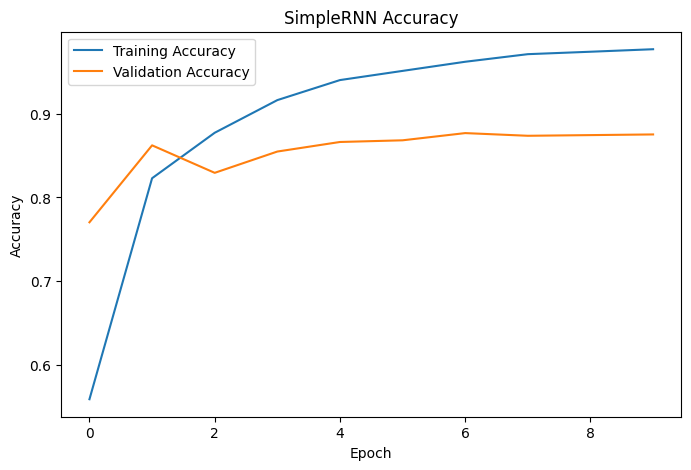

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("SimpleRNN Accuracy")
plt.legend()
plt.show()

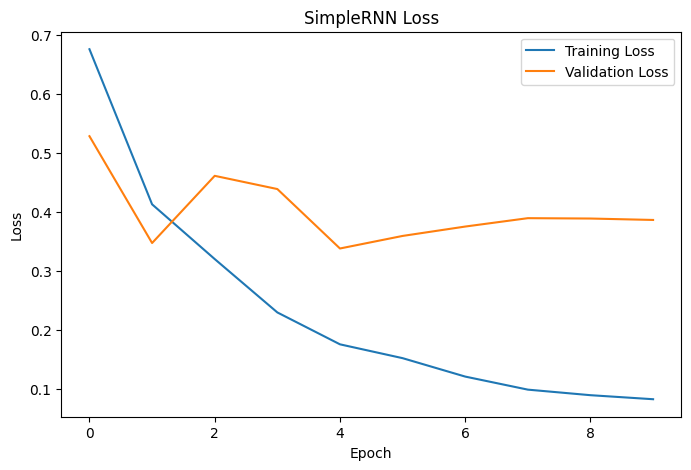

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("SimpleRNN Loss")
plt.legend()
plt.show()

## 6. Save the final model

In [11]:
model.save("simple_rnn_imdb.keras")
print("Model saved as simple_rnn_imdb.keras")

Model saved as simple_rnn_imdb.keras


## 7. Prediction helper

This prediction code is improved from the online version. It handles punctuation and keeps unknown/out-of-vocabulary words consistent with the IMDB dataset.

In [12]:
def decode_review(encoded_review):
    return " ".join([reverse_word_index.get(i - 3, "?") for i in encoded_review])


def preprocess_text(text):
    text = re.sub(r"[^a-zA-Z']", " ", text.lower())
    words = text.split()

    encoded_review = [1]  # start token
    for word in words:
        index = word_index.get(word)
        if index is None:
            encoded_review.append(2)  # OOV token
        else:
            index = index + 3
            encoded_review.append(index if index < max_features else 2)

    padded_review = sequence.pad_sequences([encoded_review], maxlen=max_len)
    return padded_review


def predict_sentiment(review):
    preprocessed_input = preprocess_text(review)
    prediction = model.predict(preprocessed_input, verbose=0)[0][0]
    sentiment = "Positive" if prediction > 0.5 else "Negative"
    return sentiment, float(prediction)

In [13]:
example_review = "This movie was fantastic! The acting was great and the plot was thrilling."

sentiment, score = predict_sentiment(example_review)

print(f"Review: {example_review}")
print(f"Sentiment: {sentiment}")
print(f"Prediction Score: {score:.4f}")

Review: This movie was fantastic! The acting was great and the plot was thrilling.
Sentiment: Positive
Prediction Score: 0.8750


In [14]:
example_review = "The movie was boring, slow, and a complete waste of time."

sentiment, score = predict_sentiment(example_review)

print(f"Review: {example_review}")
print(f"Sentiment: {sentiment}")
print(f"Prediction Score: {score:.4f}")

Review: The movie was boring, slow, and a complete waste of time.
Sentiment: Negative
Prediction Score: 0.0031


## Optional: if you still want the online-style ReLU SimpleRNN

Use this only if you really want ReLU. It is more stable than the online version because it uses lower learning rate, `clipnorm`, and `he_normal`. Do **not** run this cell together with the main model unless you want to replace the model above.

In [ ]:
# Optional ReLU SimpleRNN version
# Run this instead of the main model cell if you specifically want ReLU.

# tf.keras.backend.clear_session()
#
# model = Sequential(name="stable_relu_simple_rnn_imdb")
# model.add(Input(shape=(max_len,)))
# model.add(Embedding(input_dim=max_features, output_dim=128, mask_zero=True, name="embedding"))
# model.add(SimpleRNN(
#     128,
#     activation="relu",
#     kernel_initializer="he_normal",
#     recurrent_initializer="orthogonal",
#     name="simple_rnn_relu"
# ))
# model.add(Dropout(0.4))
# model.add(Dense(64, activation="relu"))
# model.add(Dropout(0.3))
# model.add(Dense(1, activation="sigmoid"))
#
# optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001, clipnorm=1.0)
# model.compile(optimizer=optimizer, loss="binary_crossentropy", metrics=["accuracy"])
# model.summary()